# Testes das funcoes objetivo (Markowitz, Sharpe, VaR e CVaR)

O notebook roda as classes *callable* implementadas em `Utils/financial_module.py` (`MeanVariance`, `SharpeIndex`, `VaR` e `CVaR`) para algumas composicoes de carteira **arbitrarias**, usando dados reais ja extraidos pelo `extraction_module`.

**A otimização de carteira ainda não está implementada** ... o notebook:

1. Testa as diferentes funções com composicoes fixas;
2. Compara os resultados entre carteiras diferentes;
3. Visualizar as distribuições de retorno e o VaR/CVaR.

## 1. Setup



In [2]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# a raiz do projeto e a pasta pai de Tests/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "Tests" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from Utils.extraction_module import StockDataWarehouse, StockDataFetcher
from Utils.financial_module import StockPortfolio, MeanVariance, SharpeIndex, VaR, CVaR

%matplotlib inline
pd.set_option("display.float_format", lambda x: f"{x:,.5f}")

## 2. Carregamento dos dados (preços e retornos)

Utiliza-se o `StockDataWarehouse` implementado no `extraction_module` (cache salvo em `Outputs/stocks/warehouse.pkl`, com paramêtros e ativos definidos em `Params/stocks.json`), evitando um novo download via `yfinance`. A partir do painel de precos ajustados calculam-se os retornos simples diarios de cada ativo, que formam a matriz `R` (T x N) usada por todas as classes.

In [4]:
with open(PROJECT_ROOT / "Params" / "stocks.json", encoding="utf-8") as f:
    stock_params = json.load(f)

warehouse = StockDataWarehouse(StockDataFetcher(stock_params["start_date"], stock_params["end_date"]))
warehouse.load(str(PROJECT_ROOT / "Outputs" / "stocks" / "warehouse.pkl"))

tickers = warehouse.list_stocks()
n_assets = len(tickers)
TRADING_DAYS = stock_params.get("trading_days_per_year", 252)

price_panel = warehouse.price_panel()
returns_panel = price_panel.pct_change().dropna(how="any")
R = returns_panel[tickers].to_numpy()  # matriz (T, n_assets) de retornos diarios

print(f"Ativos ({n_assets}): {tickers}")
print(f"Retornos: {R.shape[0]} observacoes diarias x {R.shape[1]} ativos")
returns_panel.head()

Ativos (10): ['AAPL', 'MSFT', 'JNJ', 'JPM', 'PG', 'XOM', 'CAT', 'HD', 'NEE', 'LIN']
Retornos: 4023 observacoes diarias x 10 ativos


,AAPL,MSFT,JNJ,JPM,PG,XOM,CAT,HD,NEE,LIN
Date,,,,,,,,,,
2010-01-05,0.00173,0.00032,-0.01160,0.01937,0.00033,0.00390,0.01196,0.00733,-0.00977,-0.01864
2010-01-06,-0.01591,-0.00614,0.00813,0.00549,-0.00474,0.00864,0.00304,-0.00346,0.00986,0.00887
2010-01-07,-0.00185,-0.01040,-0.00714,0.01981,-0.00542,-0.00314,0.00404,0.01181,-0.00282,0.00260
2010-01-08,0.00665,0.00690,0.00344,-0.00246,-0.00132,-0.00401,0.01123,-0.00481,-0.00866,0.00655
2010-01-11,-0.00882,-0.01272,0.00016,-0.00336,-0.00397,0.01122,0.06281,-0.02830,-0.00076,0.00945


# Tickers — Portfólio Diversificado (EUA)

| Ticker | Empresa | Setor |
|--------|---------|-------|
| AAPL | Apple | Tecnologia (hardware/eletrônicos de consumo) |
| MSFT | Microsoft | Tecnologia (software/cloud) |
| JNJ | Johnson & Johnson | Saúde (farmacêutico/dispositivos médicos) |
| JPM | JPMorgan Chase | Financeiro (banco) |
| PG | Procter & Gamble | Consumo básico (bens de consumo) |
| XOM | Exxon Mobil | Energia (petróleo e gás) |
| CAT | Caterpillar | Industrial (máquinas pesadas) |
| HD | Home Depot | Consumo discricionário (varejo de construção) |
| NEE | NextEra Energy | Utilities (energia elétrica/renováveis) |
| LIN | Linde | Materiais básicos (gases industriais) |

## 3. Composicoes de carteira arbitrarias

Definem-se quatro carteiras com a classe (@dataclass) criada (`StockPortfolio`) com composições escolhidas a dedo, apenas para haver cenários distintos para comparar as funções objetivo:

- **Equal Weight**: 1/N em cada ativo;
- **Concentrado (AAPL/MSFT)**: concentra 70% do capital em dois ativos (de tecnologia), dividindo o restante entre os demais;
- **Defensivo (JNJ/PG/NEE)**: sobrepondera setores defensivos (saude, consumo basico e utilidade publica);
- **Aleatorio**: pesos sorteados (com seed fixa para poder reproduzir).
- **Reduzido**: Corte com peso 0 em 5 dos tickers, efetivamente reduzindo o tamanho da carteira de forma forçada.

In [ ]:
rng = np.random.default_rng(42)
random_weights = rng.dirichlet(np.ones(n_assets))
reduced = random_weights.copy()
reduced[(rng.random(5,)*n_assets).astype(int)]=0
reduced = reduced/sum(reduced)

portfolios = {
    "Equal Weight": StockPortfolio(
        stocks=tuple(tickers),
        composition=tuple(np.repeat(1 / n_assets, n_assets)),
    ),
    "Concentrado (AAPL/MSFT)": StockPortfolio(
        stocks=tuple(tickers),
        composition=tuple([0.35, 0.35] + [0.30 / (n_assets - 2)] * (n_assets - 2)),
    ),
    "Defensivo (JNJ/PG/NEE)": StockPortfolio(
        stocks=tuple(tickers),
        composition=tuple(
            0.25 if ticker in ("JNJ", "PG", "NEE") else 0.25 / (n_assets - 3)
            for ticker in tickers
        ),
    ),
    "Aleatorio (seed=42)": StockPortfolio(
        stocks=tuple(tickers), 
        composition=tuple(random_weights)
    ),
    "Reduzido (seed=42)": StockPortfolio(
        stocks=tuple(tickers),
        composition=tuple(reduced)
    ),

}

composition_table = pd.DataFrame(
    {name: p.composition for name, p in portfolios.items()}, index=tickers
)
composition_table

,Equal Weight,Concentrado (AAPL/MSFT),Defensivo (JNJ/PG/NEE),Aleatorio (seed=42),Reduzido (seed=42)
AAPL,0.10000,0.35000,0.03571,0.16462,0.20545
MSFT,0.10000,0.35000,0.03571,0.15997,0.19964
JNJ,0.10000,0.03750,0.25000,0.16329,0.20379
JPM,0.10000,0.03750,0.03571,0.01916,0.00000
PG,0.10000,0.03750,0.25000,0.00592,0.00000
XOM,0.10000,0.03750,0.03571,0.09947,0.12414
CAT,0.10000,0.03750,0.03571,0.09655,0.00000
HD,0.10000,0.03750,0.03571,0.21393,0.26699
NEE,0.10000,0.03750,0.25000,0.00543,0.00000
LIN,0.10000,0.03750,0.03571,0.07166,0.00000


## 4. Parametros da analise

- `ALPHA`: nivel de significancia do VaR/CVaR (5%);
- `BINS`: numero de bins dos histogramas usados para suavizar visualmente a distribuição dos retornos;
- `CAPITAL`: capital simbolico (R$ 100.000,00), convertendo os retornos fracionarios (%) em valores monetarios equivalentes;
- `rf_daily`: taxa livre de risco diaria usada pelo `SharpeIndex`, a partir de uma taxa anual arbitraria de 4% a.a. ilustrativa.

In [32]:
ALPHA = 0.05
BINS = 100
CAPITAL = 100_000.0  # capital simbolico, em R$, usado so para converter % em valor monetario

rf_annual = 0.04
rf_daily = (1 + rf_annual) ** (1 / TRADING_DAYS) - 1

## 5. Instanciando as funcoes objetivo 

Cada classe é configurada uma unica vez (numero de ativos, `alpha`, taxa livre de risco) e depois reaproveitada em todas as carteiras, chamando o objeto diretamente. Essa formulação permite que um mesmo objeto de função objetivo se alinhe apenas com carteiras que deveriam poder ser comparadas uma com a outra e retenha memória de que tipo ed carteira é.

In [33]:
mean_variance = MeanVariance(n_assets=n_assets)
sharpe_index = SharpeIndex(n_assets=n_assets, rf=rf_daily)

var_non_parametric = VaR(n_assets=n_assets, alpha=ALPHA, type="non-parametric") # mesmo que histórico
var_parametric = VaR(n_assets=n_assets, alpha=ALPHA, type="parametric")
cvar_non_parametric = CVaR(n_assets=n_assets, alpha=ALPHA, type="non-parametric") # mesmo que histórico
cvar_parametric = CVaR(n_assets=n_assets, alpha=ALPHA, type="parametric")

for obj in (mean_variance, sharpe_index, var_non_parametric, var_parametric, cvar_non_parametric, cvar_parametric):
    print(repr(obj))

<Object: Callable MeanVariance> (n_assets=10)
<Object: Callable SharpeIndex> (n_assets=10; rf=0.0001556498627912628)
<Object: Callable VaR> (n_assets=10; alpha=0.05; type=non-parametric)
<Object: Callable VaR> (n_assets=10; alpha=0.05; type=parametric)
<Object: Callable CVaR> (n_assets=10; alpha=0.05; type=non-parametric)
<Object: Callable CVaR> (n_assets=10; alpha=0.05; type=parametric)


## 6. Calculo das funcoes objetivo para cada composicao

Para cada carteira: convertemos `composition` em um vetor de pesos `w`, chamamos `mean_variance(w, R)` e `sharpe_index(w, R)` (que operam diretamente sobre pesos + retornos dos ativos), e agregamos os retornos da carteira (`ret_p = R @ w`) para alimentar `VaR`/`CVaR`, que recebem a serie de retornos ja consolidada da carteira. Alem dos valores em % (retorno fracionario), calculamos tambem o equivalente em R$ aplicando `CAPITAL`.

In [34]:
rows = []
portfolio_returns = {}

for name, portfolio in portfolios.items():
    w = np.array(portfolio.composition)

    mu_p, sigma2_p = mean_variance(w, R)
    sharpe = sharpe_index(w, R)

    ret_p = R @ w
    portfolio_returns[name] = ret_p

    var_np_value, _ = var_non_parametric(ret_p)
    var_p_value, _, _ = var_parametric(ret_p)
    cvar_np_value, _, _ = cvar_non_parametric(ret_p)
    cvar_p_value = cvar_parametric(ret_p)

    mu_annual = mu_p * TRADING_DAYS
    sigma_annual = np.sqrt(sigma2_p * TRADING_DAYS)

    rows.append({
        "Portfolio": name,
        "mu_p anual (%)": mu_annual,
        "sigma_p anual (%)": sigma_annual,
        "Sharpe (diario)": sharpe,
        "VaR 5% NP (%)": var_np_value,
        "VaR 5% P (%)": var_p_value,
        "CVaR 5% NP (%)": cvar_np_value,
        "CVaR 5% P (%)": cvar_p_value,
        "mu_p anual (R$)": mu_annual * CAPITAL,
        "sigma_p anual (R$)": sigma_annual * CAPITAL,
        "VaR 5% NP (R$)": var_np_value * CAPITAL,
        "VaR 5% P (R$)": var_p_value * CAPITAL,
        "CVaR 5% NP (R$)": cvar_np_value * CAPITAL,
        "CVaR 5% P (R$)": cvar_p_value * CAPITAL,
    })

summary = pd.DataFrame(rows).set_index("Portfolio")
summary

,mu_p anual (%),sigma_p anual (%),Sharpe (diario),VaR 5% NP (%),VaR 5% P (%),CVaR 5% NP (%),CVaR 5% P (%),mu_p anual (R$),sigma_p anual (R$),VaR 5% NP (R$),VaR 5% P (R$),CVaR 5% NP (R$),CVaR 5% P (R$)
Portfolio,,,,,,,,,,,,,
Equal Weight,0.17340,0.16326,0.05177,-0.01466,-0.01623,-0.02398,-0.02053,"17,339.59039","16,326.19765","-1,466.24441","-1,622.84803","-2,397.91674","-2,052.59689"
Concentrado (AAPL/MSFT),0.22046,0.20073,0.05687,-0.01907,-0.01992,-0.02928,-0.02521,"22,045.57760","20,073.12772","-1,906.58932","-1,992.41553","-2,927.95344","-2,520.79353"
Defensivo (JNJ/PG/NEE),0.14352,0.14597,0.04501,-0.01326,-0.01455,-0.02085,-0.01840,"14,352.01384","14,596.53065","-1,325.79122","-1,455.48225","-2,085.22059","-1,839.70168"
Aleatorio (seed=42),0.19026,0.17263,0.05512,-0.01631,-0.01713,-0.02543,-0.02168,"19,026.03765","17,262.69975","-1,631.32577","-1,713.19242","-2,543.19317","-2,167.59250"
Reduzido (seed=42),0.19269,0.17376,0.05564,-0.01623,-0.01724,-0.02547,-0.02181,"19,268.81923","17,375.60571","-1,623.17343","-1,723.92787","-2,547.37258","-2,181.29993"


Na tabela, diferenciando P (paramétrico) e NP (não paramétrico), já podem ser vistos alguns dos efeitos da forma como definimos os vetores de pesos e da diferença nas abordagens de cálculo. Principalmente olhando para VaR e CVaR, vemos que os resultados não-paramétricos consistentemente retornam perdas maiores do que as encontradas pelo CVaR paramétrico, demonstrando efetivamente a capacidade do método NP de capturar o risco de cauda. Entre os diferentes métodos, nota-se também como a carteira defensiva rende o menor valor-em-risco condicional, como era de se esperar. O resultado de retorno médios e variância também parecem condizentes, indicando como a abordagem defensiva, embora seja a mais segura, também tem os menores retornos, enquanto a concentrada, de maior risco, tem os maiores.

As observações feitas a partir da tabela comparativa acima indicam que a implementação esta de acordo com o que se esperaria observar teóricamente.

## 7. Visualizacao comparativa entre carteiras

Linha de cima em retorno fracionario (%), linha de baixo no equivalente monetario sobre um capital simbolico de R$ 100.000,00 (`CAPITAL`).

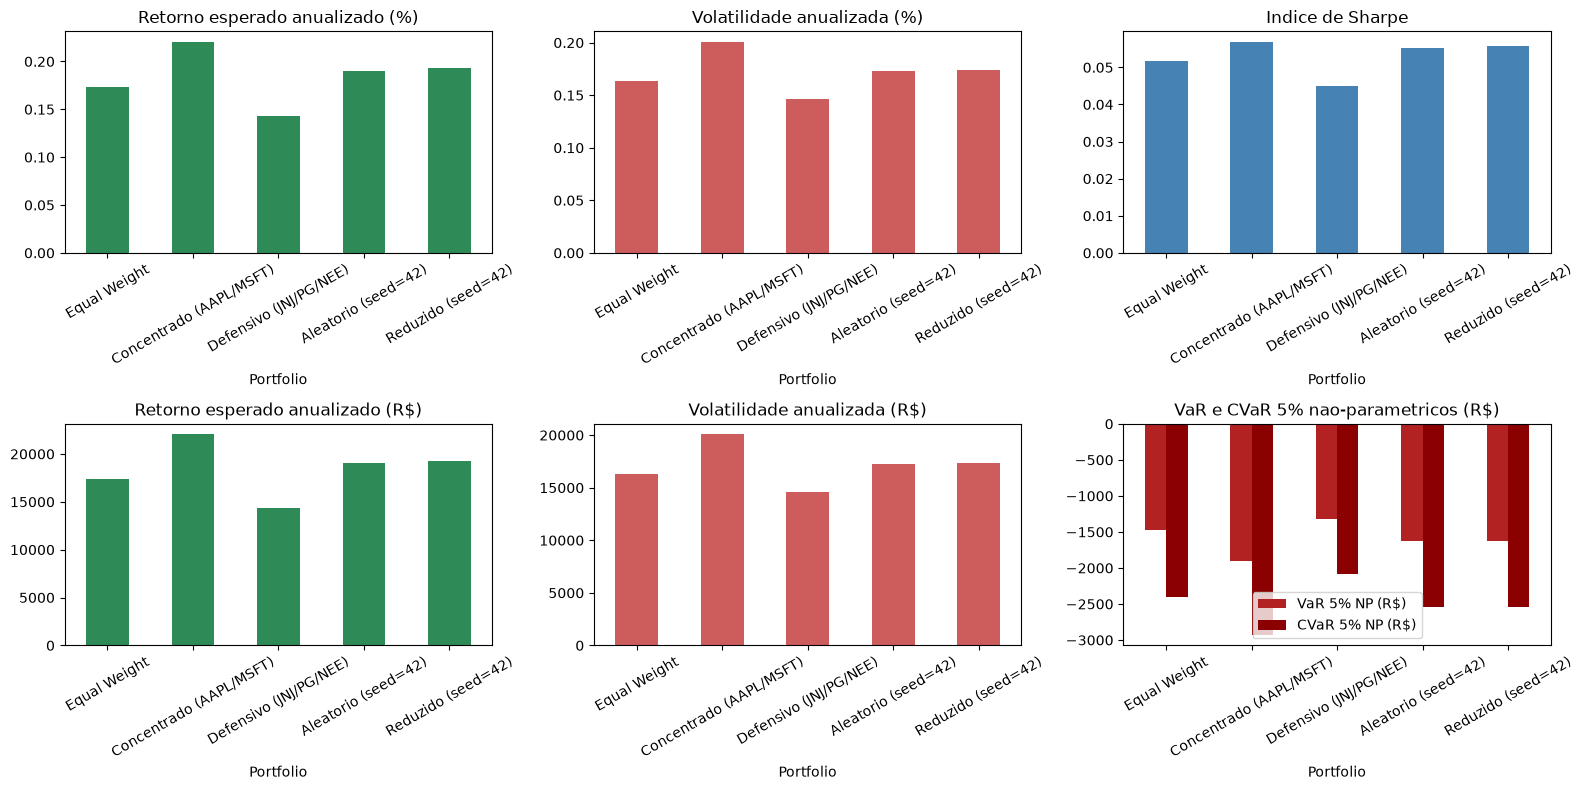

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

summary["mu_p anual (%)"].plot(kind="bar", ax=axes[0, 0], color="seagreen")
axes[0, 0].set_title("Retorno esperado anualizado (%)")

summary["sigma_p anual (%)"].plot(kind="bar", ax=axes[0, 1], color="indianred")
axes[0, 1].set_title("Volatilidade anualizada (%)")

summary["Sharpe (diario)"].plot(kind="bar", ax=axes[0, 2], color="steelblue")
axes[0, 2].set_title("Indice de Sharpe")

summary["mu_p anual (R$)"].plot(kind="bar", ax=axes[1, 0], color="seagreen")
axes[1, 0].set_title("Retorno esperado anualizado (R$)")

summary["sigma_p anual (R$)"].plot(kind="bar", ax=axes[1, 1], color="indianred")
axes[1, 1].set_title("Volatilidade anualizada (R$)")

summary[["VaR 5% NP (R$)", "CVaR 5% NP (R$)"]].plot(kind="bar", ax=axes[1, 2], color=["firebrick", "darkred"])
axes[1, 2].set_title("VaR e CVaR 5% nao-parametricos (R$)")

for ax in axes.ravel():
    ax.tick_params(axis="x", rotation=30)
fig.tight_layout()

## 8. Distribuicao de retornos, VaR e CVaR por carteira

Visualizam-se as distribuições utilizando `CVaR.plotDistribution` (modo nao-parametrico) sobre a serie de retornos de cada carteira.

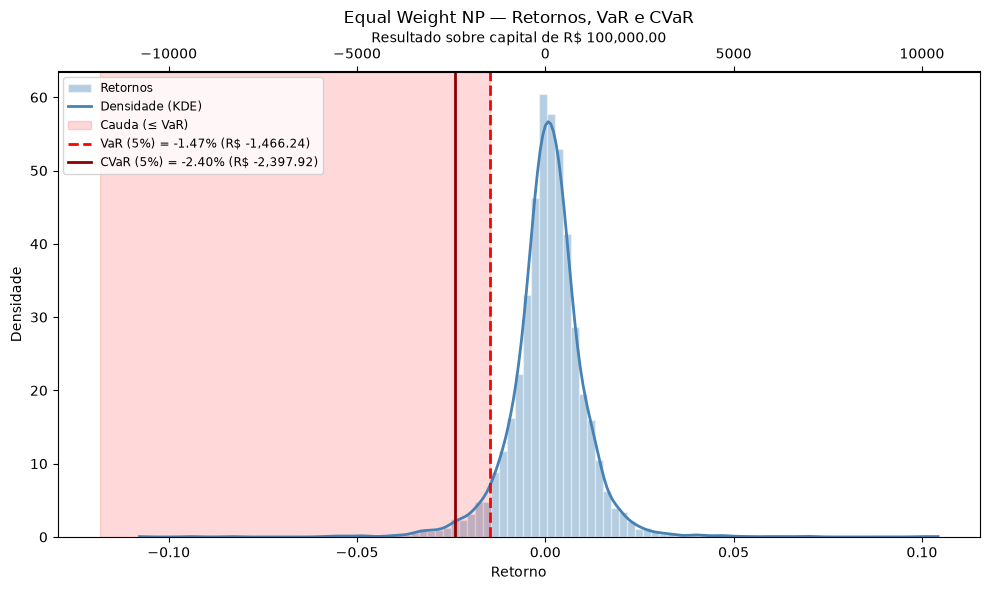

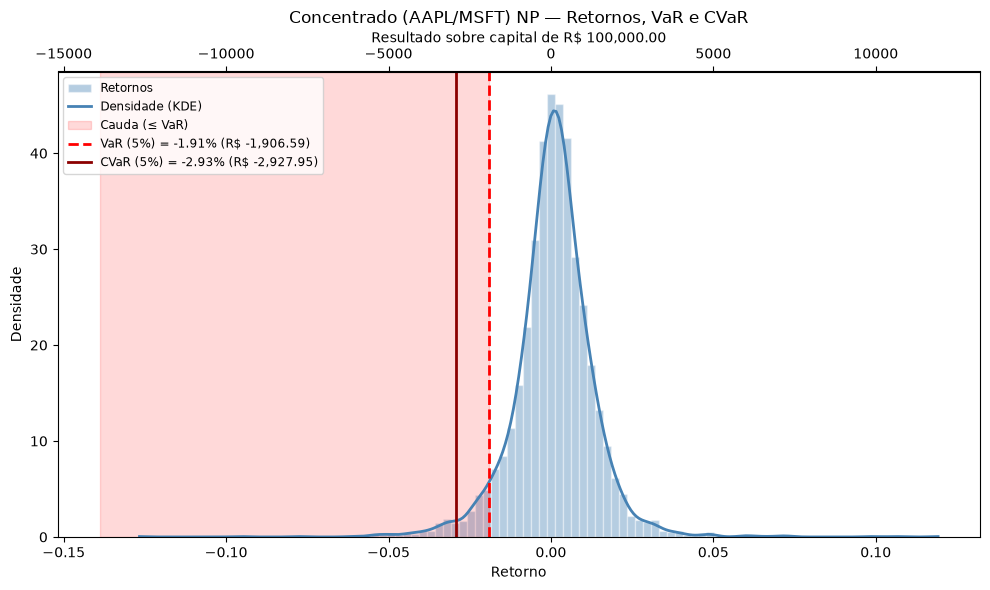

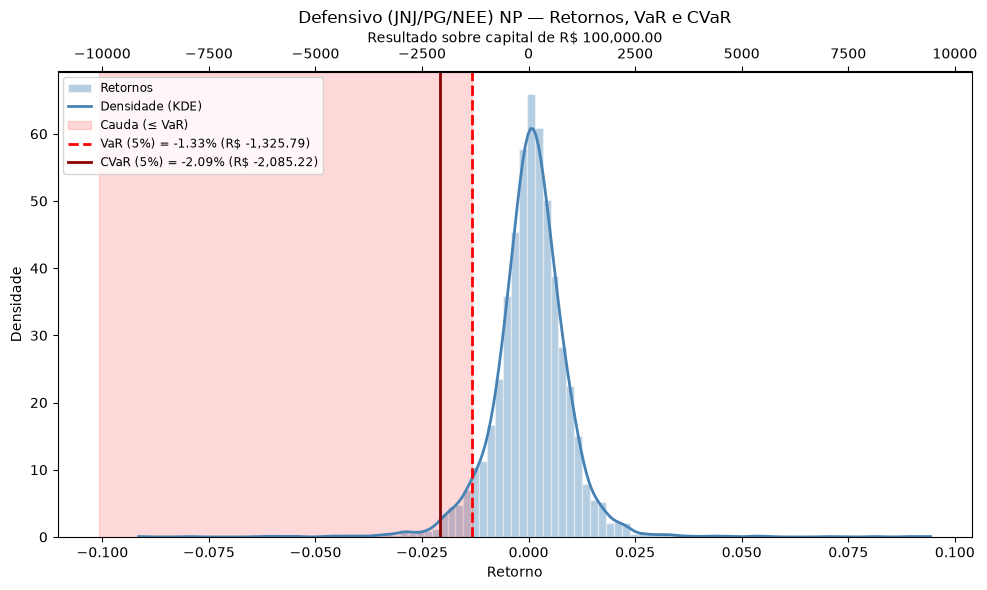

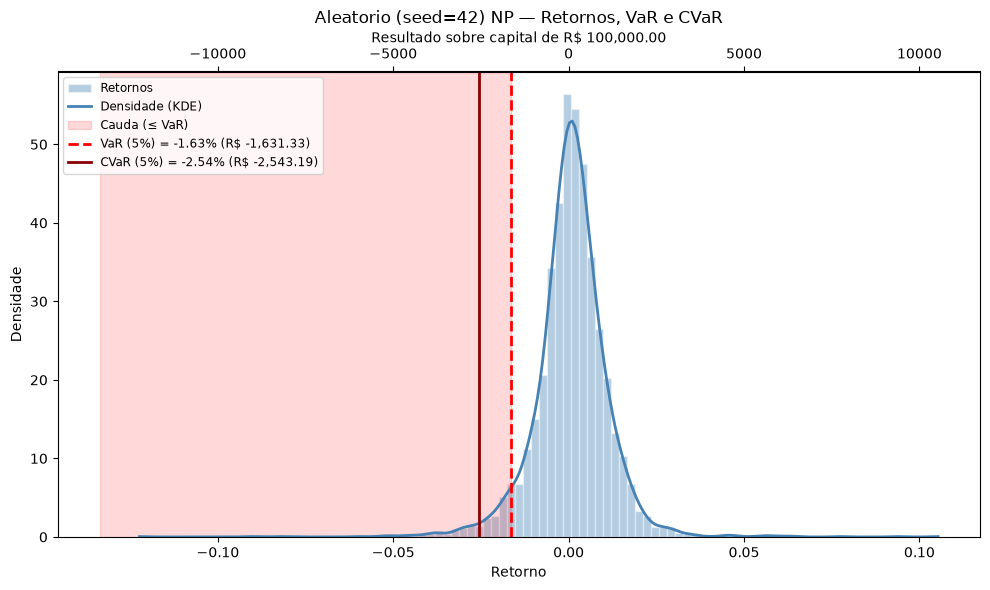

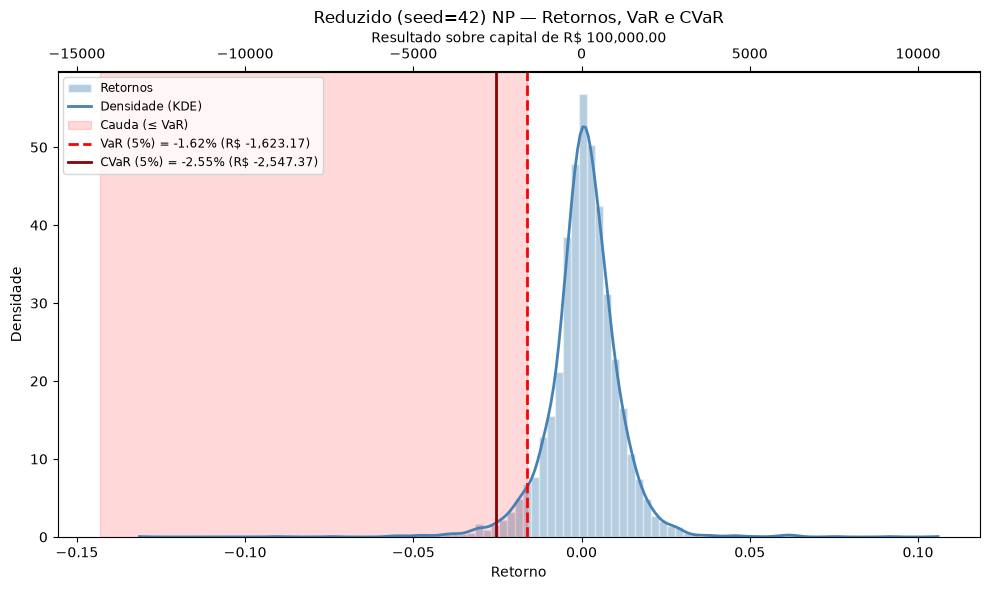

In [40]:
for name, ret_p in portfolio_returns.items():
    cvar_non_parametric.plotDistribution(
        ret_p, bins=BINS, capital=CAPITAL, title=f"{name} NP — Retornos, VaR e CVaR"
    )

## 9. Conferindo o modo parametrico

Para conseguir comparar visualmente o problema do risco de cauda, são plotados abaixo os gráficos utilizando o método paramétrico, para o qual o plot também sobrepõe a distribuição histórica como ferramenta comparativa.

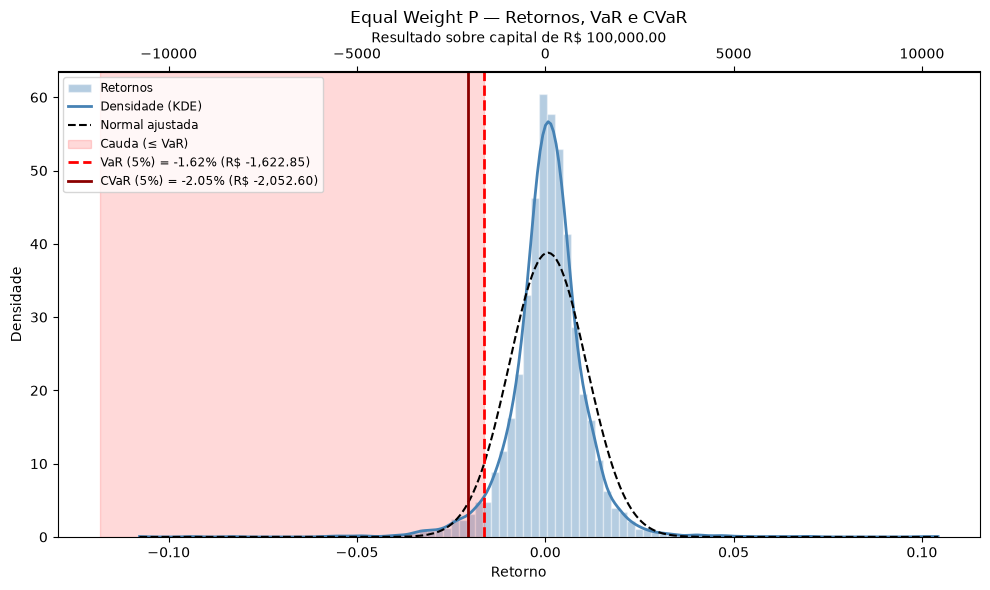

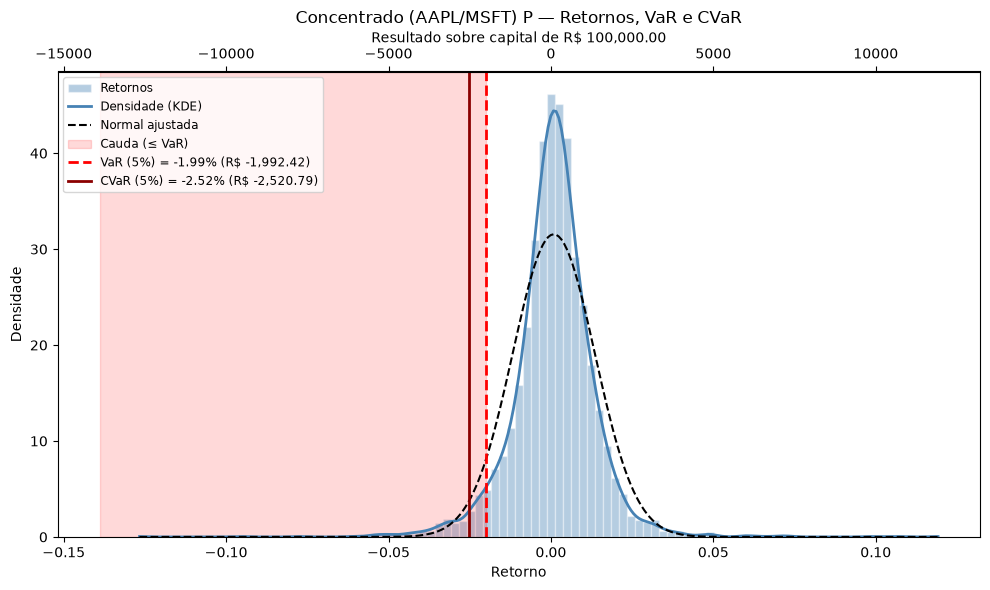

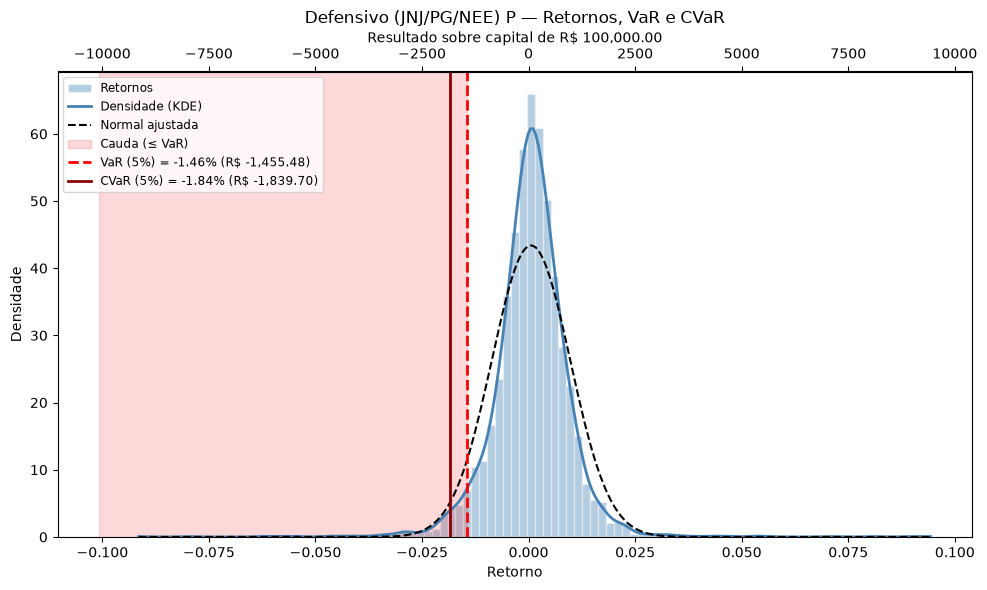

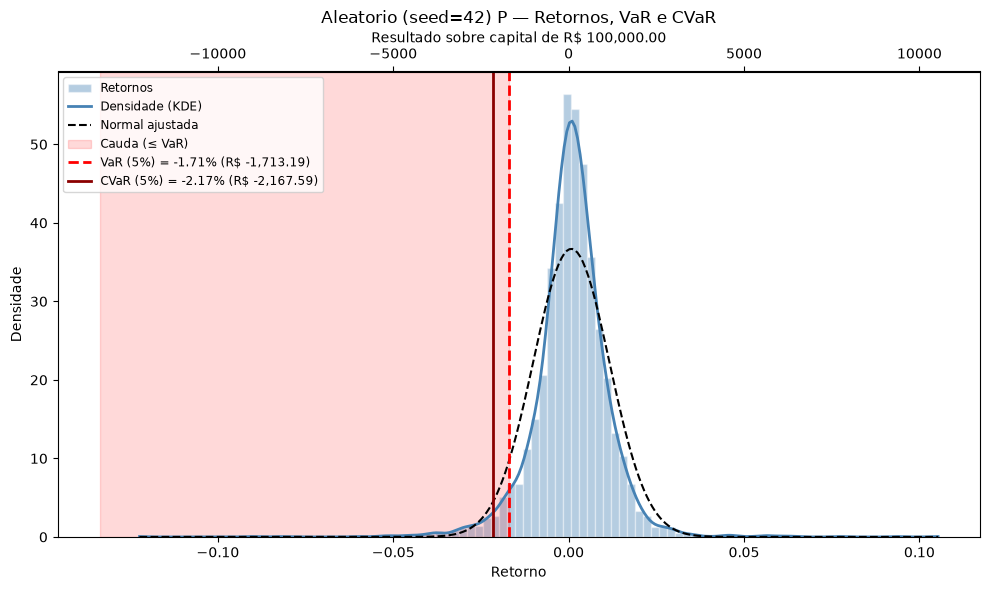

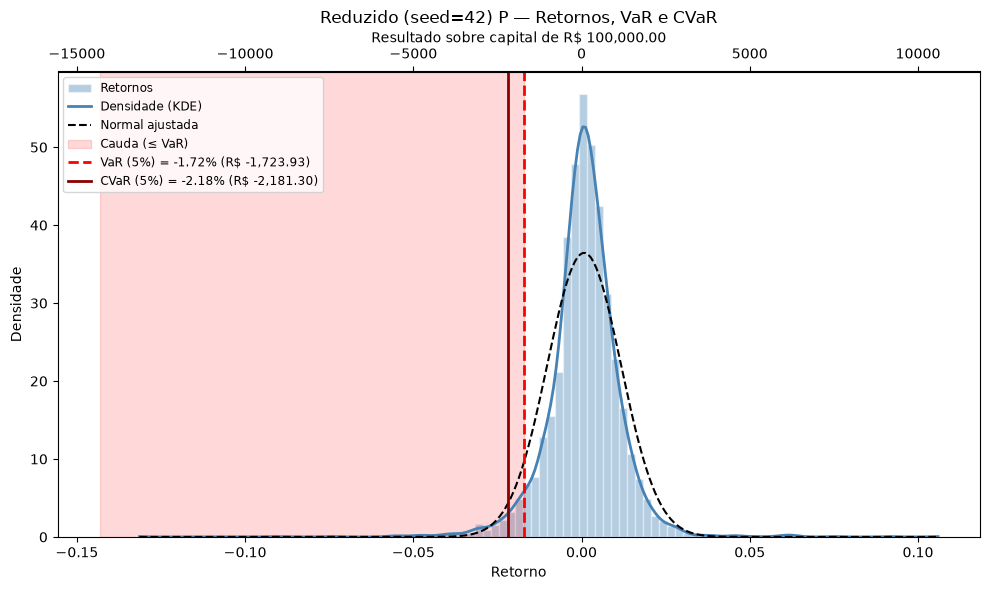

In [41]:
for name, ret_p in portfolio_returns.items():
    cvar_parametric.plotDistribution(
        ret_p, bins=BINS, capital=CAPITAL, title=f"{name} P — Retornos, VaR e CVaR"
    )